# EXPLORE DATA CENTER DATA

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#import data
data=pd.read_csv("/content/data_center_hybrid.csv")

# Study the data

In [ ]:
data.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [ ]:
data[data['Year']==2025]['WUE_L_per_kWh'].mean()

np.float64(0.777771397018222)

In [ ]:
print(data.columns)
print(data.size)
print(data.shape)
print(data.dtypes)

Index(['Year', 'Facility_ID', 'Facility_Name', 'Owner_Company', 'City',
       'Country', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
       'Cooling_System_Type', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh',
       'Daily_Water_Usage_Gallons', 'Surrounding_Water_Stress_Tier'],
      dtype='object')
1774780
(126770, 14)
Year                               int64
Facility_ID                       object
Facility_Name                     object
Owner_Company                     object
City                              object
Country                           object
Facility_Type                     object
Estimated_Capacity_MW            float64
PUE                              float64
Cooling_System_Type               object
WUE_L_per_kWh                    float64
Daily_Electricity_Usage_MWh      float64
Daily_Water_Usage_Gallons        float64
Surrounding_Water_Stress_Tier     object
dtype: object


In [ ]:
data.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


In [ ]:
data.isnull().sum()

,0
Year,0
Facility_ID,0
Facility_Name,0
Owner_Company,0
City,0
Country,0
Facility_Type,0
Estimated_Capacity_MW,0
PUE,0
Cooling_System_Type,0


In [ ]:
#check for unknown values in city and country columns
print(data[data['City']=="Unknown"]['City'].count())
print(data[data['Country']=="Unknown"]['Country'].count())

#too much missing in city column hence drop
data=data.drop('City',axis=1)

#check unique values in country column
data['Country'].unique()

#check count of unique values in country
data['Country'].nunique() #344 contadicts count of real countries -195

61418
2296


344

In [ ]:
#cleaning country col

#install pycountry
!pip install pycountry

#import pycountry
import pycountry

#creating function to extract country name
def standardise_country(name):
  try:
    return pycountry.countries.lookup(name).name
  except LookupError:
    return 'Unknown'

#apply function on Country
data['Country_cleaned']=data['Country'].apply(standardise_country)

#checking for count of cleaned rows
data[data['Country']!=data['Country_cleaned']][['Country','Country_cleaned']]

#updating to data
data['Country'] = data['Country_cleaned']

#drop country_cleaned
data=data.drop('Country_cleaned',axis=1)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 75.1 MB/s eta 0:00:00


In [ ]:
#checking if any facility has dropped in PUE
pue_2019=data[data['Year']==2019][['Facility_ID','PUE']]
pue_2025=data[data['Year']==2025][['Facility_ID','PUE']]
merged=pd.merge(pue_2019,pue_2025,on='Facility_ID')
merged[merged['PUE_x']<merged['PUE_y']]

,Facility_ID,PUE_x,PUE_y


In [ ]:
#selecting only object cols
obj_cols=data.select_dtypes('object').columns
obj_cols

data[obj_cols].describe()

,Facility_ID,Facility_Name,Owner_Company,Country,Facility_Type,Cooling_System_Type,Surrounding_Water_Stress_Tier
count,126770,126770,126770,126770,126770,126770,126770
unique,18110,16286,4180,148,3,3,3
top,DC-31D8B15E,Amsterdam,Amazon AWS,United States,Enterprise/Standard,Air Cooled,Medium
freq,7,231,3731,61726,105189,79541,46718


In [ ]:
#finding most frequent value in each object column
modes=data[obj_cols].mode().iloc[0]
modes

for x in obj_cols:
  count=data[data[x]==modes[x]].drop_duplicates('Facility_ID')[x].count()
  print (f"Major {x} is {modes[x]} with {count}" )

Major Facility_ID is DC-0006E5D5 with 1
Major Facility_Name is Amsterdam with 33
Major Owner_Company is Amazon AWS with 533
Major Country is United States with 8818
Major Facility_Type is Enterprise/Standard with 15027
Major Cooling_System_Type is Air Cooled with 11363
Major Surrounding_Water_Stress_Tier is Medium with 6674


In [ ]:
#finding units with same name but different ID's
data4=data[['Facility_ID','Facility_Name']].drop_duplicates('Facility_ID')
data4=data4[data4['Facility_Name'].duplicated(keep=False)]
data4

,Facility_ID,Facility_Name
0,DC-D2763E00,NAP de las Americas Madrid
140,DC-7E6FA42D,1-Net North
147,DC-1C251301,1-Net North
273,DC-07D9C4B3,111 8th Avenue
280,DC-ACB1D8C1,111 8th Avenue
...,...,...
126490,DC-991347E1,Romania Data Center
126497,DC-34966485,Romania Data Center
126658,DC-F850AC3C,Istanbul Data Center
126721,DC-4E292700,Istanbul Data Center


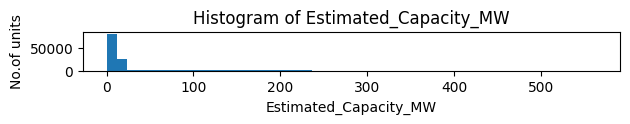

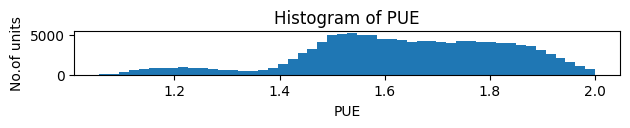

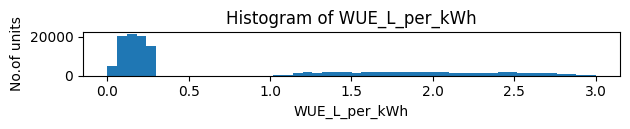

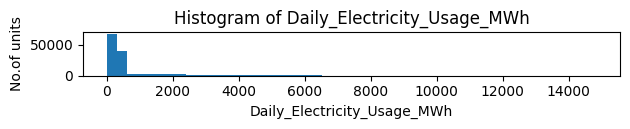

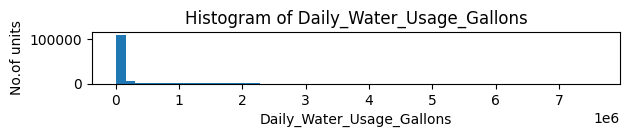

In [ ]:
#plotting histogram for numerical columns
float_cols=data.select_dtypes('float64').columns
for i,col in enumerate(float_cols,1):
  plt.subplot(len(float_cols),1,i)
  plt.hist(data[col], bins=50)
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('No.of units')
  plt.tight_layout()
  plt.show()

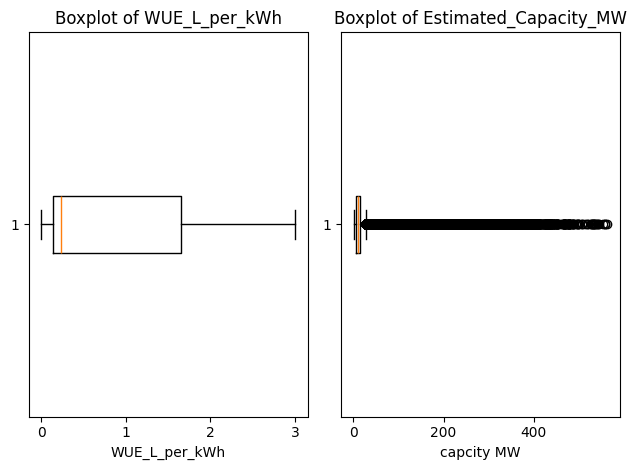

In [ ]:
#plotting boxplot for WUE and capacity to study distribution
plt.subplot(1,2,1)
plt.boxplot(data['WUE_L_per_kWh'],vert=False)
plt.title(f'Boxplot of WUE_L_per_kWh')
plt.xlabel('WUE_L_per_kWh')

plt.subplot(1,2,2)
plt.boxplot(data['Estimated_Capacity_MW'], vert=False)
plt.title(f'Boxplot of Estimated_Capacity_MW')
plt.xlabel('capcity MW')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Avg WUE (L/kWh)')

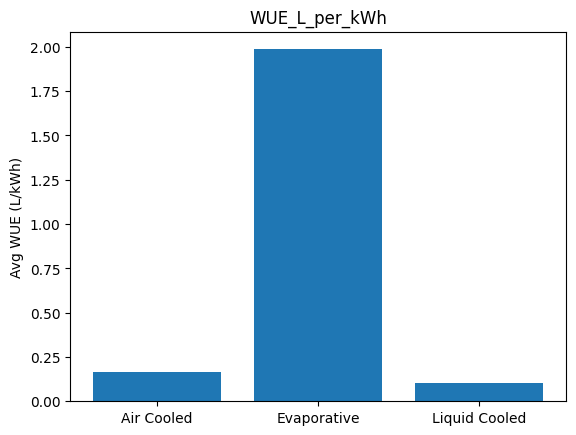

In [ ]:
#study relation b/w cooling type and water consumption

avg_water_efficiency=data.groupby('Cooling_System_Type')['WUE_L_per_kWh'].mean()
avg_water_efficiency

plt.bar(avg_water_efficiency.index,avg_water_efficiency.values)
plt.title('WUE_L_per_kWh')
plt.ylabel('Avg WUE (L/kWh)')

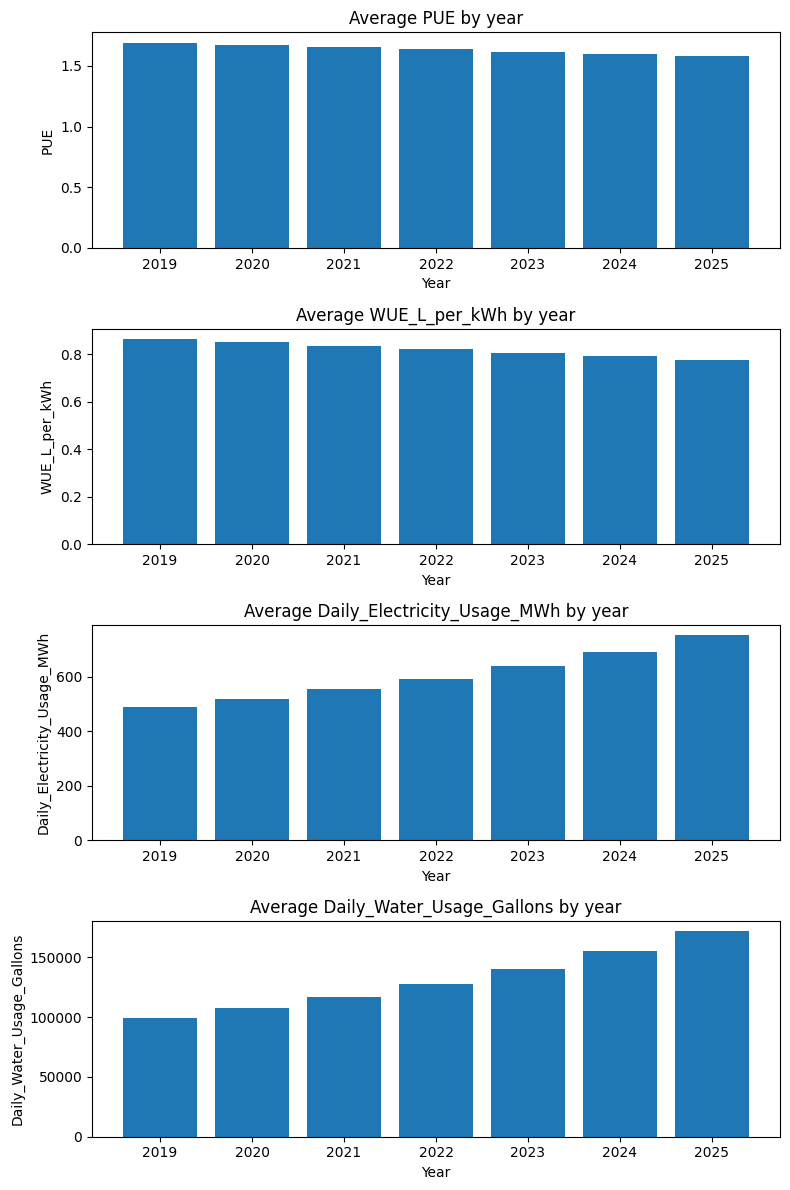

In [ ]:
#studying variance of metrics across years
metric_cols=['PUE','WUE_L_per_kWh','Daily_Electricity_Usage_MWh','Daily_Water_Usage_Gallons']

plt.figure(figsize=(8, 12))

for i,col in enumerate(metric_cols,1):
  avg = data.groupby('Year')[col].mean()
  plt.subplot(len(metric_cols),1,i)
  plt.bar(avg.index,avg.values)
  plt.title(f'Average {col} by year' )
  plt.ylabel(col)
  plt.xlabel('Year')

plt.tight_layout()
plt.show()




In [ ]:
# Quick correlation check
data[['PUE','WUE_L_per_kWh','Estimated_Capacity_MW',
      'Daily_Electricity_Usage_MWh']].corr()

,PUE,WUE_L_per_kWh,Estimated_Capacity_MW,Daily_Electricity_Usage_MWh
PUE,1.000000,-0.160029,-0.601272,-0.576587
WUE_L_per_kWh,-0.160029,1.000000,0.182441,0.184339
Estimated_Capacity_MW,-0.601272,0.182441,1.000000,0.983549
Daily_Electricity_Usage_MWh,-0.576587,0.184339,0.983549,1.000000


In [ ]:
# Top 10 worst PUE facilities in 2025
worst = data[data['Year']==2025].nlargest(10, 'PUE')[
    ['Facility_Name','Country','PUE','Estimated_Capacity_MW','Cooling_System_Type']]
worst

,Facility_Name,Country,PUE,Estimated_Capacity_MW,Cooling_System_Type
13341,DediPower Thames Valley Hosting Centre,United Kingdom,1.944,1.14,Air Cooled
82130,SDC Austin Data Center,United States,1.928,13.16,Air Cooled
124809,Taulov Data Center,Denmark,1.926,7.32,Air Cooled
727,17222 Von Karman Ave,United States,1.923,14.91,Evaporative
110424,STT Noida 2,India,1.919,10.07,Air Cooled
10646,Coeur D'Alene,United States,1.918,9.75,Evaporative
12375,Data Centre 1,United Kingdom,1.918,13.42,Air Cooled
73310,Tierpoint Dallas - Allen Data Center,United States,1.917,13.99,Air Cooled
51715,Evocative JFK2,United States,1.916,12.44,Evaporative
26865,Moscow,Unknown,1.915,15.74,Air Cooled


In [ ]:
data.groupby('Cooling_System_Type')['PUE'].mean()

,PUE
Cooling_System_Type,
Air Cooled,1.670127
Evaporative,1.591939
Liquid Cooled,1.337023


In [ ]:
data.groupby('Facility_Type')['PUE'].mean()

,PUE
Facility_Type,
Colocation,1.479179
Enterprise/Standard,1.693435
Hyperscale/AI,1.210476


In [ ]:
#creating new for PUE
bins = [0,1.3,1.5,1.7,2.0,float('inf')]
labels = ['excellent','good','average','poor','critical']
data['Pue_Category']=pd.cut(data['PUE'],bins=bins,labels=labels)
data

,Year,Facility_ID,Facility_Name,Owner_Company,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier,Pue_Category
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low,poor
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low,poor
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low,poor
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low,poor
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low,poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126765,2021,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,14.51,1.495,Evaporative,2.305,381.65,155454.82,High,good
126766,2022,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,14.77,1.485,Evaporative,2.281,378.59,153627.09,High,good
126767,2023,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,15.04,1.473,Evaporative,2.245,319.36,128626.89,High,good
126768,2024,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,15.31,1.450,Evaporative,2.231,394.69,160407.53,High,good


In [ ]:
print(data.groupby('Year')['PUE'].mean())

Year
2019    1.692697
2020    1.674050
2021    1.655636
2022    1.637350
2023    1.619222
2024    1.601400
2025    1.583868
Name: PUE, dtype: float64


In [ ]:
data.to_csv('data_center_cleaned.csv', index=False)

## Key Findings

1. **PUE improved consistently** from 1.693 (2019) to 1.584 (2025) — 6.5% efficiency gain
2. **Hyperscale/AI facilities** are 28% more efficient than Enterprise (PUE: 1.21 vs 1.69)
3. **Liquid cooling** is 20% more efficient than Air Cooling (PUE: 1.34 vs 1.67)
4. **Evaporative cooling** uses 13x more water than Liquid Cooling (WUE: 2.0 vs 0.10 L/kWh)
5. **Larger facilities are more efficient** — strong negative correlation (r = -0.60) between capacity and PUE
6. **Absolute electricity and water usage are rising** despite efficiency gains — capacity growth outpaces improvement
7. **Top worst performer in 2025**: DediPower Thames Valley (UK) at PUE 1.944
8. **United States dominates** with 8,818 unique facilities — largest single-country footprint

In [ ]:
data2=pd.read_csv("/content/data_center_cleaned.csv")
data2

,Year,Facility_ID,Facility_Name,Owner_Company,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier,Pue_Category
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low,poor
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low,poor
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low,poor
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low,poor
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low,poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126765,2021,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,14.51,1.495,Evaporative,2.305,381.65,155454.82,High,good
126766,2022,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,14.77,1.485,Evaporative,2.281,378.59,153627.09,High,good
126767,2023,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,15.04,1.473,Evaporative,2.245,319.36,128626.89,High,good
126768,2024,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Türkiye,Enterprise/Standard,15.31,1.450,Evaporative,2.231,394.69,160407.53,High,good


In [ ]:
data['Daily_Electricity_Usage_MWh'].sum()

np.float64(76724039.56)